<a href="https://colab.research.google.com/github/vaishnavigandla04/Car_price_prediction/blob/main/sales_prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# ==========================================================
# SALES PREDICTION USING MACHINE LEARNING
# ==========================================================

# Import Required Libraries

import pandas as pd
import numpy as np

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor

from sklearn.metrics import (
    mean_absolute_error,
    mean_squared_error,
    r2_score
)



print("Libraries Imported Successfully!")

Libraries Imported Successfully!


In [ ]:
# Load Dataset

df = pd.read_csv("/Advertising.csv")

print("Dataset Loaded Successfully!")

Dataset Loaded Successfully!


In [ ]:
# Display First Five Rows

df.head()

,Unnamed: 0,TV,Radio,Newspaper,Sales
0,1,230.1,37.8,69.2,22.1
1,2,44.5,39.3,45.1,10.4
2,3,17.2,45.9,69.3,9.3
3,4,151.5,41.3,58.5,18.5
4,5,180.8,10.8,58.4,12.9


In [ ]:
df.tail()

,Unnamed: 0,TV,Radio,Newspaper,Sales
195,196,38.2,3.7,13.8,7.6
196,197,94.2,4.9,8.1,9.7
197,198,177.0,9.3,6.4,12.8
198,199,283.6,42.0,66.2,25.5
199,200,232.1,8.6,8.7,13.4


In [ ]:
print("Rows :", df.shape[0])
print("Columns :", df.shape[1])

Rows : 200
Columns : 5


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column      Non-Null Count  Dtype  
---  ------      --------------  -----  
 0   Unnamed: 0  200 non-null    int64  
 1   TV          200 non-null    float64
 2   Radio       200 non-null    float64
 3   Newspaper   200 non-null    float64
 4   Sales       200 non-null    float64
dtypes: float64(4), int64(1)
memory usage: 7.9 KB


In [ ]:
df.describe()

,Unnamed: 0,TV,Radio,Newspaper,Sales
count,200.000000,200.000000,200.000000,200.000000,200.000000
mean,100.500000,147.042500,23.264000,30.554000,14.022500
std,57.879185,85.854236,14.846809,21.778621,5.217457
min,1.000000,0.700000,0.000000,0.300000,1.600000
25%,50.750000,74.375000,9.975000,12.750000,10.375000
50%,100.500000,149.750000,22.900000,25.750000,12.900000
75%,150.250000,218.825000,36.525000,45.100000,17.400000
max,200.000000,296.400000,49.600000,114.000000,27.000000


In [ ]:
df.isnull().sum()

,0
Unnamed: 0,0
TV,0
Radio,0
Newspaper,0
Sales,0


In [ ]:
print("Duplicate Records :", df.duplicated().sum())

Duplicate Records : 0


In [ ]:
if "Unnamed: 0" in df.columns:
    df.drop("Unnamed: 0", axis=1, inplace=True)

df.head()

,TV,Radio,Newspaper,Sales
0,230.1,37.8,69.2,22.1
1,44.5,39.3,45.1,10.4
2,17.2,45.9,69.3,9.3
3,151.5,41.3,58.5,18.5
4,180.8,10.8,58.4,12.9


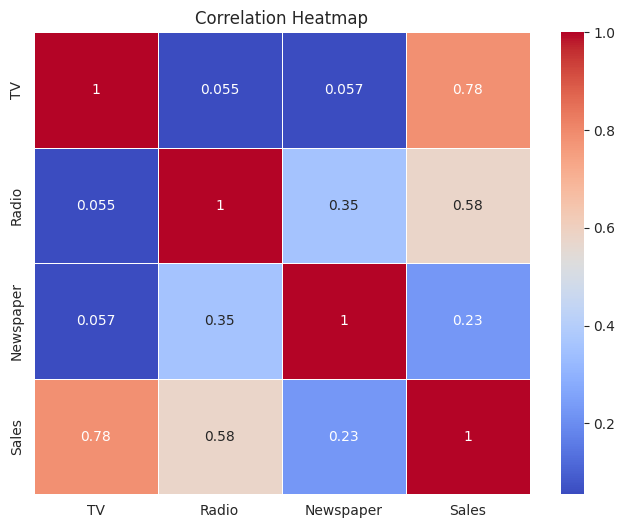

In [ ]:
#Exploratory Data Analysis
#Correlation Heatmap
plt.figure(figsize=(8,6))

sns.heatmap(
    df.corr(),
    annot=True,
    cmap="coolwarm",
    linewidths=0.5
)

plt.title("Correlation Heatmap")
plt.show()

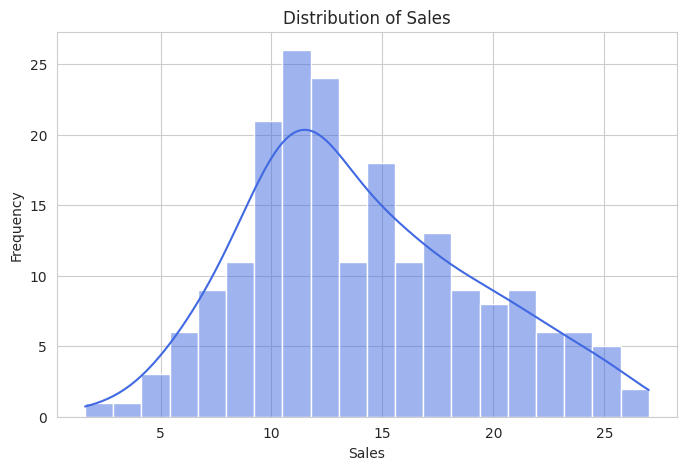

In [ ]:
#Distribution of Sales
plt.figure(figsize=(8,5))

sns.histplot(
    df["Sales"],
    bins=20,
    kde=True,
    color="royalblue"
)

plt.title("Distribution of Sales")
plt.xlabel("Sales")
plt.ylabel("Frequency")

plt.show()

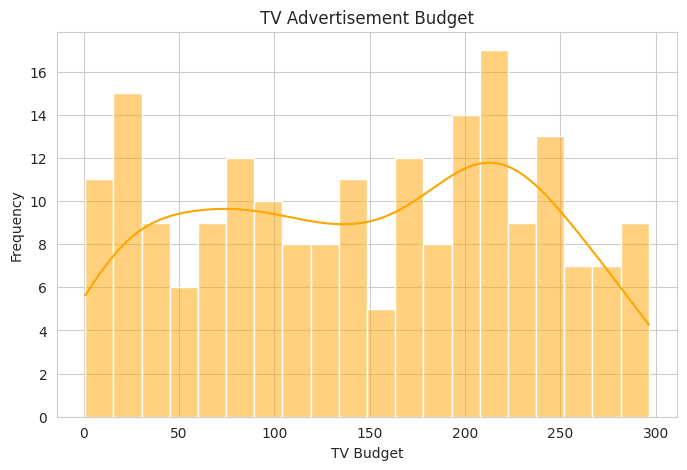

In [ ]:
#TV Advertisement Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["TV"],
    bins=20,
    kde=True,
    color="orange"
)

plt.title("TV Advertisement Budget")
plt.xlabel("TV Budget")
plt.ylabel("Frequency")

plt.show()

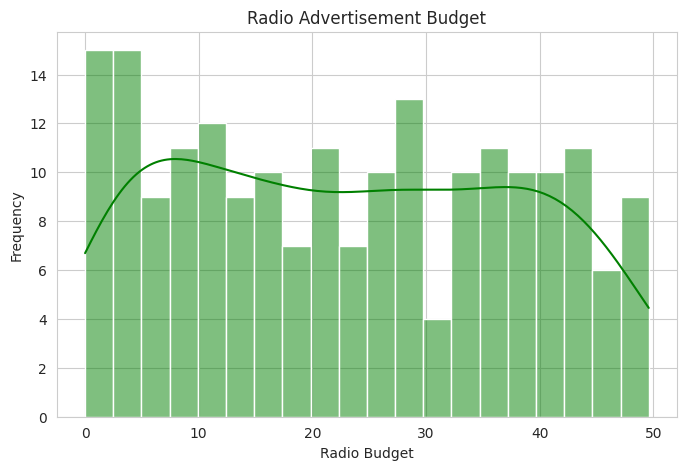

In [ ]:
#Radio Advertisement Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["Radio"],
    bins=20,
    kde=True,
    color="green"
)

plt.title("Radio Advertisement Budget")
plt.xlabel("Radio Budget")
plt.ylabel("Frequency")

plt.show()

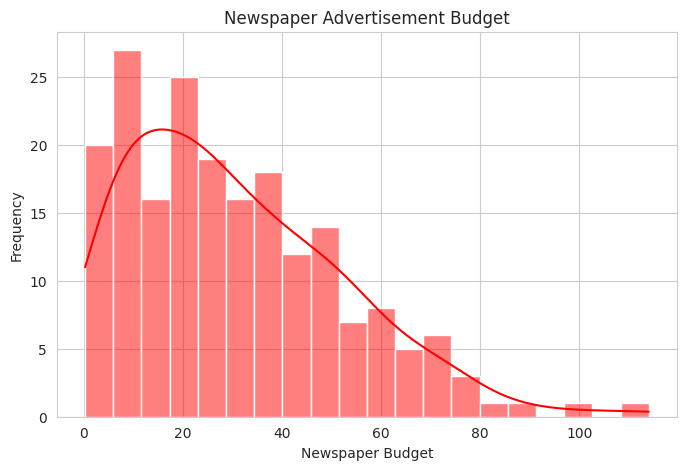

In [ ]:
#Newspaper Advertisement Distribution
plt.figure(figsize=(8,5))

sns.histplot(
    df["Newspaper"],
    bins=20,
    kde=True,
    color="red"
)

plt.title("Newspaper Advertisement Budget")
plt.xlabel("Newspaper Budget")
plt.ylabel("Frequency")

plt.show()

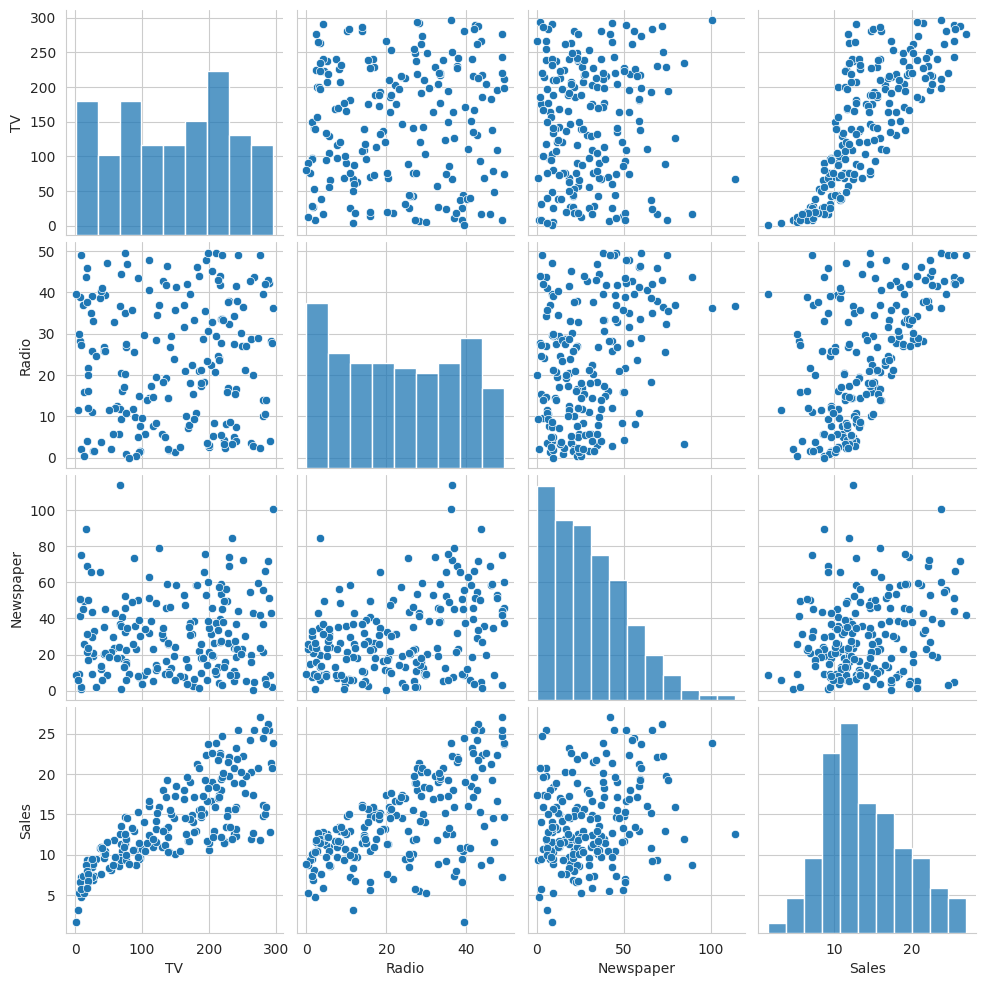

In [ ]:
#Pair Plot
sns.pairplot(df)

plt.show()

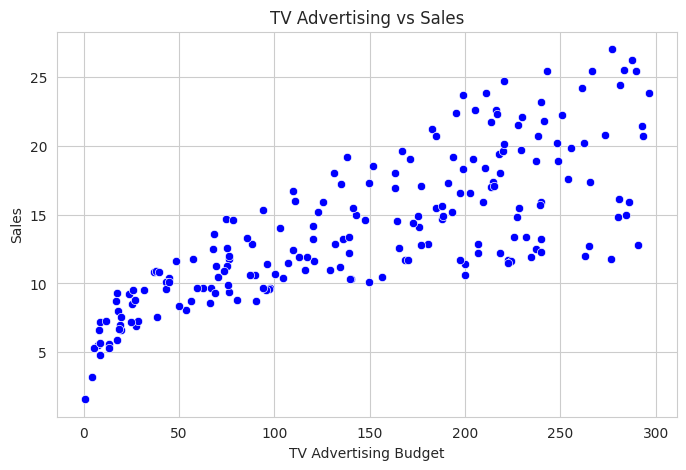

In [ ]:
#TV vs Sales
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="TV",
    y="Sales",
    data=df,
    color="blue"
)

plt.title("TV Advertising vs Sales")
plt.xlabel("TV Advertising Budget")
plt.ylabel("Sales")

plt.show()

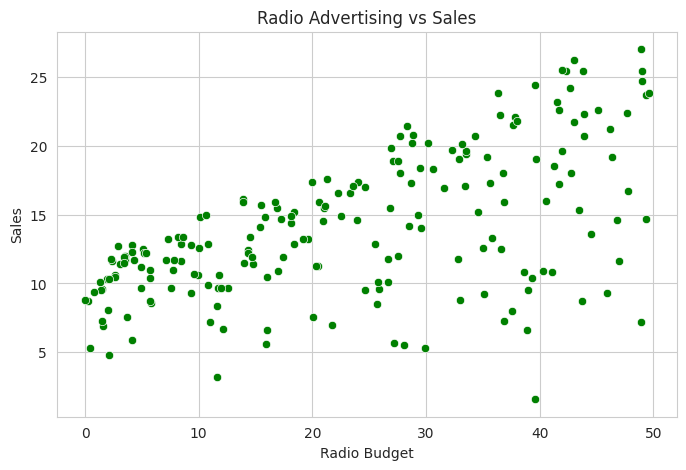

In [ ]:
#Radio vs Sales
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Radio",
    y="Sales",
    data=df,
    color="green"
)

plt.title("Radio Advertising vs Sales")

plt.xlabel("Radio Budget")
plt.ylabel("Sales")

plt.show()

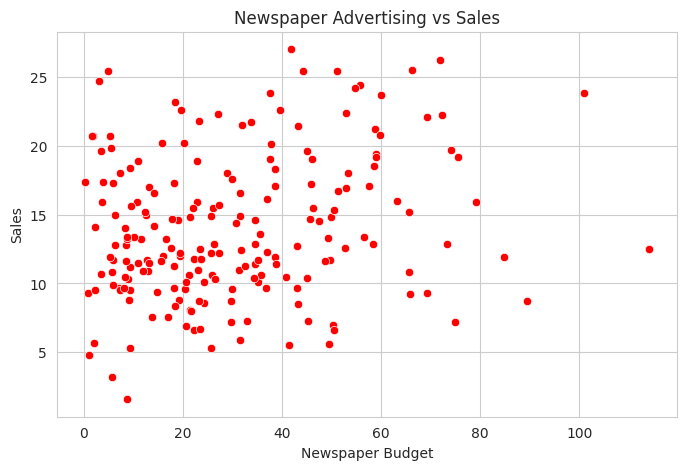

In [ ]:
#Newspaper vs Sales
plt.figure(figsize=(8,5))

sns.scatterplot(
    x="Newspaper",
    y="Sales",
    data=df,
    color="red"
)

plt.title("Newspaper Advertising vs Sales")

plt.xlabel("Newspaper Budget")
plt.ylabel("Sales")

plt.show()

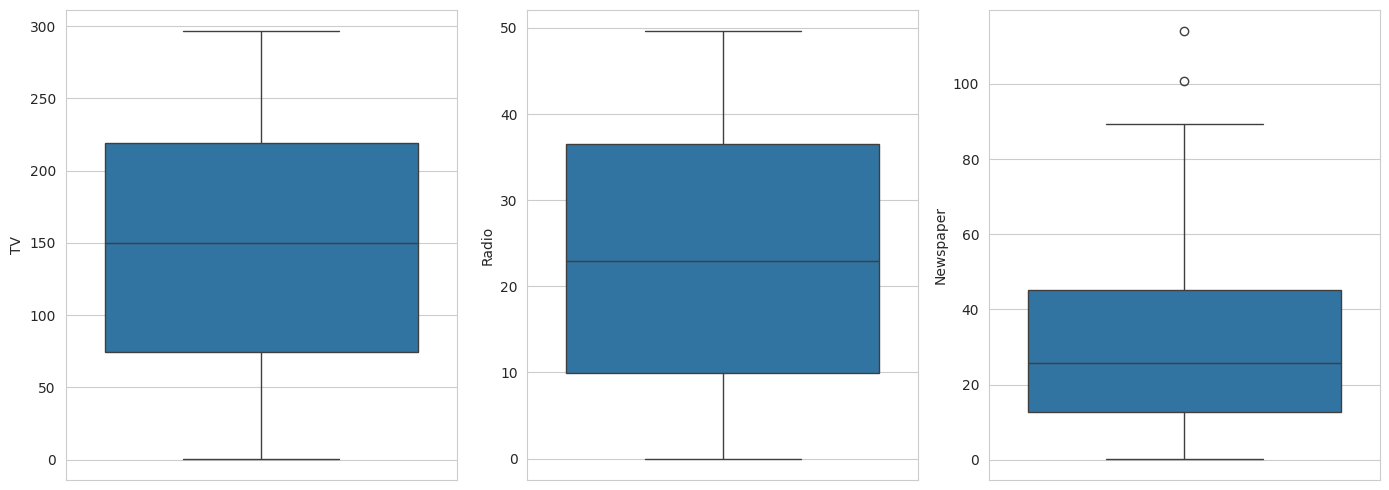

In [ ]:
#Boxplots
plt.figure(figsize=(14,5))

plt.subplot(1,3,1)
sns.boxplot(y=df["TV"])

plt.subplot(1,3,2)
sns.boxplot(y=df["Radio"])

plt.subplot(1,3,3)
sns.boxplot(y=df["Newspaper"])

plt.tight_layout()

plt.show()

In [ ]:
#Train-Test Split
# Define Features and Target

X = df.drop("Sales", axis=1)
y = df["Sales"]

print("Features Shape :", X.shape)
print("Target Shape :", y.shape)

Features Shape : (200, 3)
Target Shape : (200,)


In [ ]:
# Split Dataset

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.20,
    random_state=42
)

print("Training Data :", X_train.shape)
print("Testing Data :", X_test.shape)

Training Data : (160, 3)
Testing Data : (40, 3)


In [ ]:
#Linear Regression Model
# Create Model

linear_model = LinearRegression()

# Train Model

linear_model.fit(X_train, y_train)

print("Linear Regression Model Trained Successfully!")

Linear Regression Model Trained Successfully!


In [ ]:
# Prediction

linear_predictions = linear_model.predict(X_test)

In [ ]:
#Linear Regression Evaluation
linear_mae = mean_absolute_error(y_test, linear_predictions)

linear_mse = mean_squared_error(y_test, linear_predictions)

linear_rmse = np.sqrt(linear_mse)

linear_r2 = r2_score(y_test, linear_predictions)

print("Linear Regression Performance")
print("--------------------------------")
print("MAE :", linear_mae)
print("MSE :", linear_mse)
print("RMSE :", linear_rmse)
print("R2 Score :", linear_r2)

Linear Regression Performance
--------------------------------
MAE : 1.4607567168117603
MSE : 3.1740973539761033
RMSE : 1.78159966153345
R2 Score : 0.899438024100912


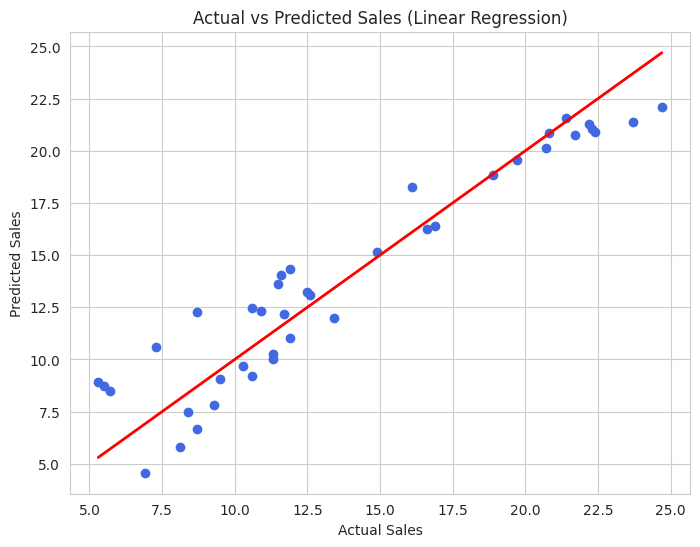

In [ ]:
#Actual vs Predicted
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    linear_predictions,
    color="royalblue"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.title("Actual vs Predicted Sales (Linear Regression)")

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.show()

In [ ]:
#Decision Tree Regressor
decision_tree = DecisionTreeRegressor(
    random_state=42
)

decision_tree.fit(X_train, y_train)

print("Decision Tree Model Trained Successfully!")
decision_tree_predictions = decision_tree.predict(X_test)

Decision Tree Model Trained Successfully!


In [ ]:
#Decision Tree Evaluation
tree_mae = mean_absolute_error(
    y_test,
    decision_tree_predictions
)

tree_mse = mean_squared_error(
    y_test,
    decision_tree_predictions
)

tree_rmse = np.sqrt(tree_mse)

tree_r2 = r2_score(
    y_test,
    decision_tree_predictions
)

print("Decision Tree Performance")
print("----------------------------")

print("MAE :", tree_mae)
print("MSE :", tree_mse)
print("RMSE :", tree_rmse)
print("R2 Score :", tree_r2)

Decision Tree Performance
----------------------------
MAE : 0.9850000000000001
MSE : 2.175
RMSE : 1.4747881203752624
R2 Score : 0.9310914968293178


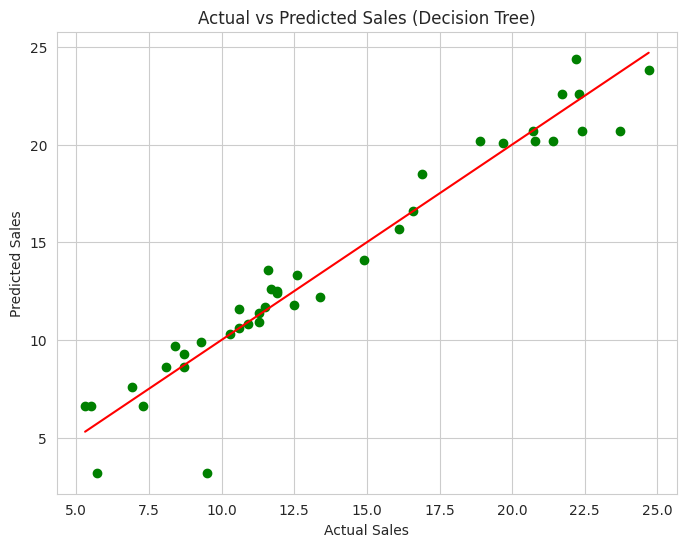

In [ ]:
#Decision Tree Plot
plt.figure(figsize=(8,6))

plt.scatter(
    y_test,
    decision_tree_predictions,
    color="green"
)

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red"
)

plt.title("Actual vs Predicted Sales (Decision Tree)")

plt.xlabel("Actual Sales")

plt.ylabel("Predicted Sales")

plt.show()

In [ ]:
#Random Forest Regressor
rf_model = RandomForestRegressor(
    n_estimators=100,
    random_state=42
)

rf_model.fit(
    X_train,
    y_train
)

print("Random Forest Model Trained Successfully!")
rf_predictions = rf_model.predict(
    X_test
)

Random Forest Model Trained Successfully!


In [ ]:
rf_mae = mean_absolute_error(y_test, rf_predictions)
rf_rmse = np.sqrt(mean_squared_error(y_test, rf_predictions))
rf_r2 = r2_score(y_test, rf_predictions)

print("Random Forest Performance")
print("--------------------------")
print("MAE :", round(rf_mae,2))
print("RMSE:", round(rf_rmse,2))
print("R² Score:", round(rf_r2,3))

Random Forest Performance
--------------------------
MAE : 0.62
RMSE: 0.77
R² Score: 0.981


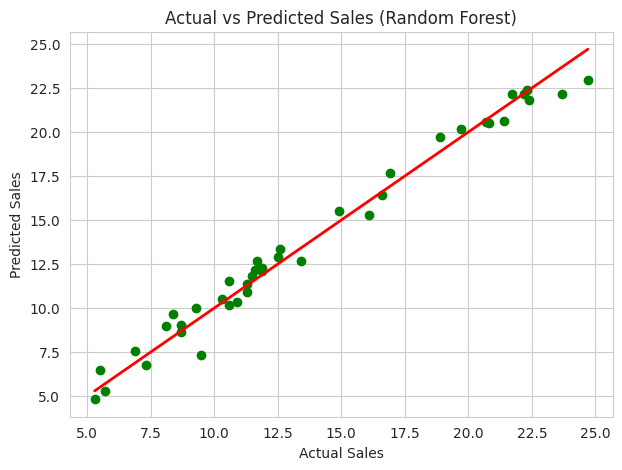

In [ ]:
#Actual vs Predicted (Random Forest)
plt.figure(figsize=(7,5))

plt.scatter(y_test, rf_predictions, color="green")

plt.plot(
    [y_test.min(), y_test.max()],
    [y_test.min(), y_test.max()],
    color="red",
    linewidth=2
)

plt.xlabel("Actual Sales")
plt.ylabel("Predicted Sales")
plt.title("Actual vs Predicted Sales (Random Forest)")
plt.show()

In [ ]:
#Model Comparison
comparison = pd.DataFrame({

    "Model":[
        "Linear Regression",
        "Decision Tree",
        "Random Forest"
    ],

    "MAE":[
        linear_mae,
        tree_mae,
        rf_mae
    ],

    "RMSE":[
        linear_rmse,
        tree_rmse,
        rf_rmse
    ],

    "R2 Score":[
        linear_r2,
        tree_r2,
        rf_r2
    ]

})

comparison

,Model,MAE,RMSE,R2 Score
0,Linear Regression,1.460757,1.781600,0.899438
1,Decision Tree,0.985000,1.474788,0.931091
2,Random Forest,0.620100,0.768591,0.981284


In [ ]:
#Best Model
comparison.sort_values(
    by="R2 Score",
    ascending=False
)

,Model,MAE,RMSE,R2 Score
2,Random Forest,0.620100,0.768591,0.981284
1,Decision Tree,0.985000,1.474788,0.931091
0,Linear Regression,1.460757,1.781600,0.899438


In [ ]:
#Feature Importance
importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": rf_model.feature_importances_
})

importance = importance.sort_values(
    by="Importance",
    ascending=False
)

importance

,Feature,Importance
0,TV,0.624810
1,Radio,0.362201
2,Newspaper,0.012989


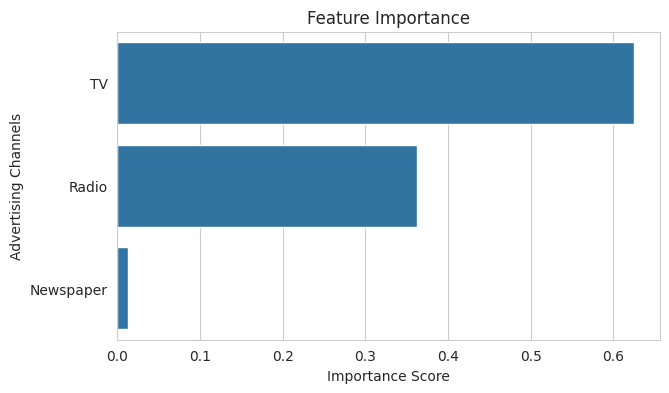

In [ ]:
plt.figure(figsize=(7,4))

sns.barplot(
    data=importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance")
plt.xlabel("Importance Score")
plt.ylabel("Advertising Channels")
plt.show()

In [ ]:
#Predict New Sales
new_data = pd.DataFrame({
    "TV": [180],
    "Radio": [35],
    "Newspaper": [40]
})

predicted_sales = rf_model.predict(new_data)

print("Predicted Sales:", round(predicted_sales[0],2))

Predicted Sales: 18.12


In [ ]:
#Business Insights
print("Business Insights")
print("-----------------")
print("1. TV advertising has the strongest impact on sales.")
print("2. Radio advertising also contributes significantly.")
print("3. Newspaper advertising has relatively low influence.")
print("4. Businesses should prioritize TV and Radio for better returns.")
print("5. Machine Learning can help optimize advertising budgets and improve sales forecasting.")

Business Insights
-----------------
1. TV advertising has the strongest impact on sales.
2. Radio advertising also contributes significantly.
3. Newspaper advertising has relatively low influence.
4. Businesses should prioritize TV and Radio for better returns.
5. Machine Learning can help optimize advertising budgets and improve sales forecasting.


In [ ]:
print("CONCLUSION")
print("-" * 40)

print("""
This project successfully analyzed advertising expenditure across
TV, Radio, and Newspaper platforms to predict product sales.

Exploratory Data Analysis revealed that TV advertising has the
strongest positive relationship with sales, followed by Radio,
while Newspaper contributes comparatively less.

Three regression algorithms were implemented:

• Linear Regression
• Decision Tree Regressor
• Random Forest Regressor

Their performance was evaluated using:

• MAE
• MSE
• RMSE
• R² Score

The best-performing model demonstrated that Machine Learning
can accurately estimate future sales using advertising budgets.

Such predictive models can help organizations optimize
marketing expenditure and improve business decision-making.
""")

CONCLUSION
----------------------------------------

This project successfully analyzed advertising expenditure across
TV, Radio, and Newspaper platforms to predict product sales.

Exploratory Data Analysis revealed that TV advertising has the
strongest positive relationship with sales, followed by Radio,
while Newspaper contributes comparatively less.

Three regression algorithms were implemented:

• Linear Regression
• Decision Tree Regressor
• Random Forest Regressor

Their performance was evaluated using:

• MAE
• MSE
• RMSE
• R² Score

The best-performing model demonstrated that Machine Learning
can accurately estimate future sales using advertising budgets.

Such predictive models can help organizations optimize
marketing expenditure and improve business decision-making.



In [ ]:
print("FUTURE SCOPE")
print("-" * 40)

print("""
1. Collect larger real-world datasets.

2. Include digital marketing channels such as:
   - Facebook Ads
   - Instagram Ads
   - Google Ads

3. Perform hyperparameter tuning.

4. Build a web application using Streamlit or Flask.

5. Deploy the trained model to the cloud.

6. Automate predictions using real-time marketing data.
""")

FUTURE SCOPE
----------------------------------------

1. Collect larger real-world datasets.

2. Include digital marketing channels such as:
   - Facebook Ads
   - Instagram Ads
   - Google Ads

3. Perform hyperparameter tuning.

4. Build a web application using Streamlit or Flask.

5. Deploy the trained model to the cloud.

6. Automate predictions using real-time marketing data.

